# Deep Dive Analysis: Delivery, Payments, and Geography

## Overview
This notebook explores advanced metrics to understand the drivers of customer satisfaction and revenue.
1.  **Delivery Performance:** Impact of delivery time on review scores.
2.  **Payment Behavior:** Preferred payment methods and installment patterns.
3.  **Geospatial Insights:** Revenue distribution across Brazilian states.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# Connect to the SQLite database
db_path = 'olist.db'
conn = sqlite3.connect(db_path)

print(f"Connected to database at: {db_path}")

Connected to database at: olist.db


## 1. Delivery Performance Analysis
Does faster delivery lead to better reviews? How often is the estimated delivery date missed?

In [3]:
query_delivery = """
SELECT 
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    r.review_score
FROM orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
"""

df_delivery = pd.read_sql(query_delivery, conn)

# Convert dates to datetime
df_delivery['order_purchase_timestamp'] = pd.to_datetime(df_delivery['order_purchase_timestamp'])
df_delivery['order_delivered_customer_date'] = pd.to_datetime(df_delivery['order_delivered_customer_date'])
df_delivery['order_estimated_delivery_date'] = pd.to_datetime(df_delivery['order_estimated_delivery_date'])

# Calculate Delivery Time (Days)
df_delivery['delivery_days'] = (df_delivery['order_delivered_customer_date'] - df_delivery['order_purchase_timestamp']).dt.days

# Calculate Delay (Actual - Estimated)
# Positive means late, Negative means early
df_delivery['delay_days'] = (df_delivery['order_delivered_customer_date'] - df_delivery['order_estimated_delivery_date']).dt.days

print(f"Average Delivery Time: {df_delivery['delivery_days'].mean():.2f} days")
print(f"Average Delay: {df_delivery['delay_days'].mean():.2f} days (Negative means early on average)")

# Correlation
corr = df_delivery[['delivery_days', 'delay_days', 'review_score']].corr()
print("\nCorrelation Matrix:")
display(corr)

Average Delivery Time: 12.06 days
Average Delay: -11.92 days (Negative means early on average)

Correlation Matrix:


,delivery_days,delay_days,review_score
delivery_days,1.000000,0.601746,-0.333616
delay_days,0.601746,1.000000,-0.267027
review_score,-0.333616,-0.267027,1.000000


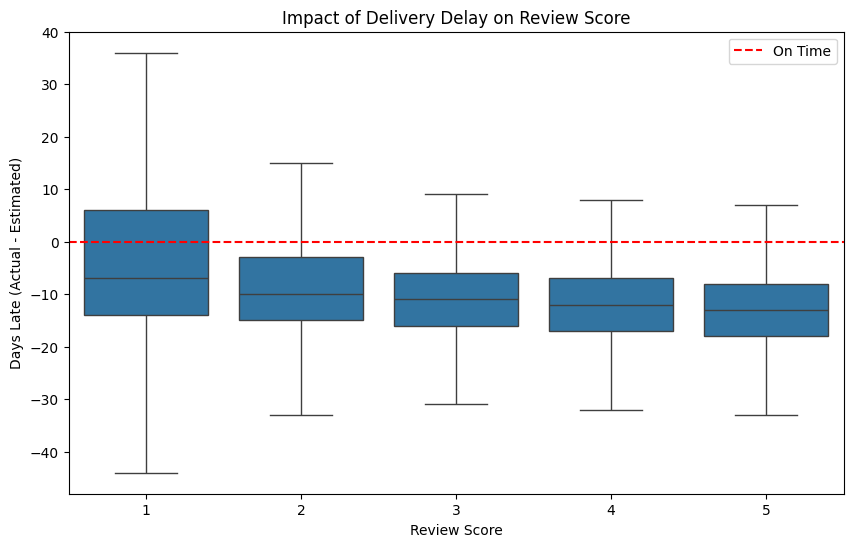

In [4]:
# Visualize Review Score vs. Delay
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delay_days', data=df_delivery, showfliers=False)
plt.title('Impact of Delivery Delay on Review Score')
plt.xlabel('Review Score')
plt.ylabel('Days Late (Actual - Estimated)')
plt.axhline(0, color='red', linestyle='--', label='On Time')
plt.legend()
plt.show()

## 2. Payment Analysis
How do customers pay? Do high-value orders use more installments?

/tmp/ipykernel_1284249/1361939756.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='payment_type', data=df_payments, order=df_payments['payment_type'].value_counts().index, palette='viridis')


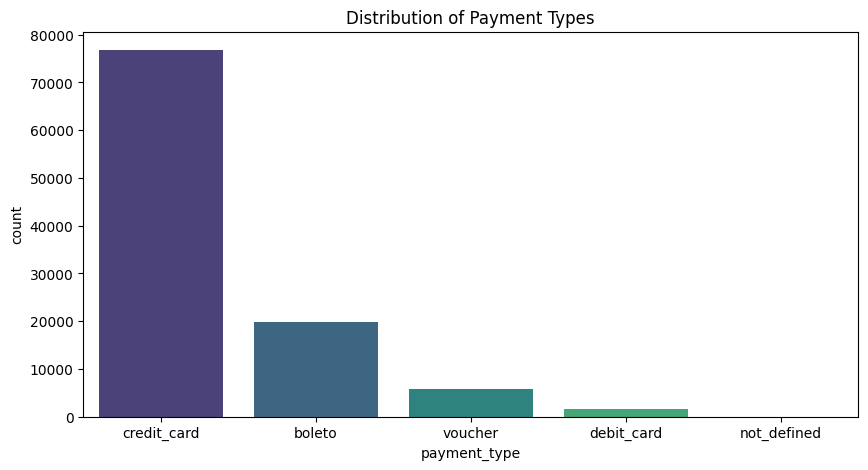

/tmp/ipykernel_1284249/1361939756.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='payment_installments', y='payment_value', data=df_payments, palette='magma')


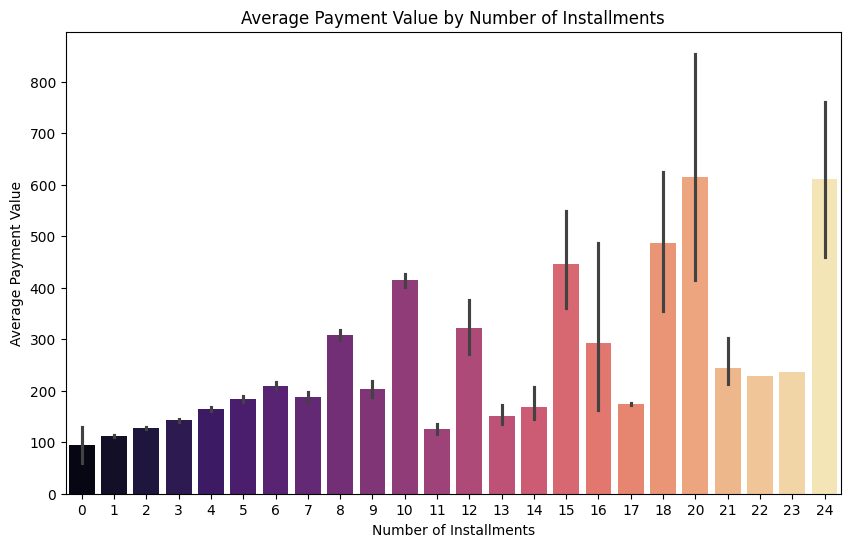

In [5]:
query_payments = """
SELECT 
    payment_type,
    payment_installments,
    payment_value
FROM order_payments
"""
df_payments = pd.read_sql(query_payments, conn)

# Payment Type Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='payment_type', data=df_payments, order=df_payments['payment_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Payment Types')
plt.show()

# Installments vs. Value
plt.figure(figsize=(10, 6))
sns.barplot(x='payment_installments', y='payment_value', data=df_payments, palette='magma')
plt.title('Average Payment Value by Number of Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Average Payment Value')
plt.show()

## 3. Geospatial Analysis
Where does the revenue come from?

/tmp/ipykernel_1284249/791459667.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='customer_state', data=df_geo.head(10), palette='Blues_r')


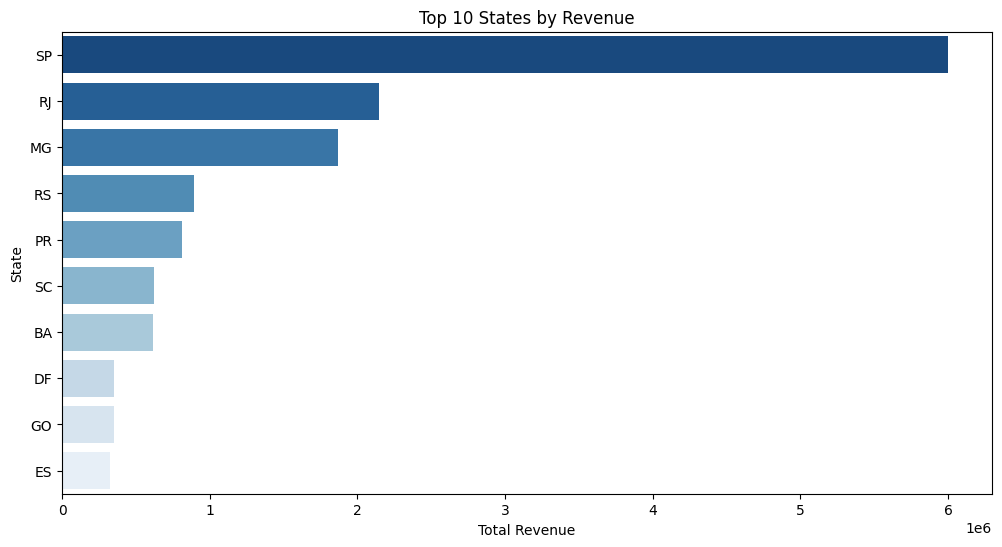

In [6]:
query_geo = """
SELECT 
    c.customer_state,
    SUM(p.payment_value) as total_revenue,
    COUNT(DISTINCT o.order_id) as total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_payments p ON o.order_id = p.order_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
"""
df_geo = pd.read_sql(query_geo, conn)

# Top 10 States by Revenue
plt.figure(figsize=(12, 6))
sns.barplot(x='total_revenue', y='customer_state', data=df_geo.head(10), palette='Blues_r')
plt.title('Top 10 States by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('State')
plt.show()